# Jouvence — PyG out-of-core proof + LaminDB remaining work

Generated for the Jouvence KG workstream.

This notebook is intentionally **evidence-driven**:

- It loads the VM smoke-test artefact from `artifacts/reports/t_fa93a782/ooc_training_smoke.json`.
- It shows that the PyG path touched all active non-provenance relations and node types without `full_graph.pt` / full `edge_index` materialization.
- It loads a LaminDB remaining-work inventory from `artifacts/reports/lamin_enhancer_autofinish/kg_lamin_remaining_inventory.json`.

The Lamin inventory included here is the completed read-only parity inventory from `txgnn-worker`: source Parquet metadata row counts plus live SQLite counts from `lnschema_txgnn_kgedge` / `lnschema_txgnn_kgedgeevidence` and mapped exact-ID node tables. It was generated while the writer was active, but completed successfully.


In [1]:
from pathlib import Path
import json
import math
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').exists() and (ROOT.parent / 'pyproject.toml').exists():
    ROOT = ROOT.parent
PYG_JSON = ROOT / 'artifacts/reports/t_fa93a782/ooc_training_smoke.json'
PYG_QA = ROOT / 'artifacts/reports/t_fa93a782/qa_report.md'
LAMIN_FAST_JSON = ROOT / 'artifacts/reports/lamin_enhancer_autofinish/kg_lamin_remaining_inventory.json'

assert PYG_JSON.exists(), PYG_JSON
assert LAMIN_FAST_JSON.exists(), LAMIN_FAST_JSON

pyg = json.loads(PYG_JSON.read_text())
lamin = json.loads(LAMIN_FAST_JSON.read_text())
print('PyG smoke:', pyg['status'], 'host=', pyg['host'], 'steps=', pyg['steps'])
print('Full Lamin inventory generated:', lamin['generated_at_utc'])


PyG smoke: pass host= txgnn-worker steps= 39
Full Lamin inventory generated: 2026-07-08T15:46:21.187142+00:00


## 1. PyG out-of-core smoke: what was actually proven

This is not the old bounded `HeteroData/full_graph.pt` proof. The smoke ran on `txgnn-worker` against a worker-local staged KG root and exercised the sampler/relation coverage path.


In [2]:
pyg_summary = {
    'status': pyg['status'],
    'host': pyg['host'],
    'elapsed_s': pyg['elapsed_s'],
    'steps': pyg['steps'],
    'relations_touched': len(pyg['relations_touched']),
    'missing_relations': len(pyg['missing_relations']),
    'node_types_touched': len(pyg['node_types_touched']),
    'missing_node_types': len(pyg['missing_node_types']),
    'peak_rss_mb': pyg['rss']['peak_mb'],
    'no_full_graph_pt': pyg['no_full_graph_pt'],
    'no_full_edge_index_materialization': pyg['no_full_edge_index_materialization'],
    'loss_first': pyg['loss']['first'],
    'loss_last': pyg['loss']['last'],
}
pd.Series(pyg_summary).to_frame('value')


,value
status,pass
host,txgnn-worker
elapsed_s,22.898
steps,39
relations_touched,39
missing_relations,0
node_types_touched,13
missing_node_types,0
peak_rss_mb,1473.644531
no_full_graph_pt,True


In [3]:
assert pyg['status'] == 'pass'
assert len(pyg['missing_relations']) == 0
assert len(pyg['missing_node_types']) == 0
assert pyg['no_full_graph_pt'] is True
assert pyg['no_full_edge_index_materialization'] is True
assert pyg['rss']['peak_mb'] < 2048
print('PASS: all PyG out-of-core acceptance checks pass.')


PASS: all PyG out-of-core acceptance checks pass.


## 2. Relations and node types touched by the PyG smoke


In [4]:
relations_df = pd.DataFrame([
    {
        'relation': rel,
        'positive_edges': metrics.get('positive_edges'),
        'negative_edges': metrics.get('negative_edges'),
        'node_types': ', '.join(metrics.get('node_types', [])),
        'loss': metrics.get('loss'),
    }
    for rel, metrics in pyg['relation_metrics'].items()
]).sort_values('relation')
node_types_df = pd.DataFrame({'node_type': pyg['node_types_touched']})
print(f"Relations touched: {len(relations_df)}")
print(f"Node types touched: {len(node_types_df)}")
display(relations_df)
display(node_types_df)


Relations touched: 39
Node types touched: 13


,relation,positive_edges,negative_edges,node_types,loss
0,cell_line_derived_from_tissue,4,4,"cell_line, tissue",0.752654
1,cell_line_expresses_gene,4,4,"cell_line, gene",0.663332
2,cell_line_from_organism,4,0,"cell_line, organism",0.555458
3,cell_type_expresses_gene,4,3,"cell_type, gene",0.656657
4,disease_associated_gene,4,4,"disease, gene",0.703498
5,disease_has_phenotype,4,4,"disease, phenotype",0.754199
6,disease_involves_pathway,4,4,"disease, pathway",0.673222
7,disease_manifests_in_tissue,4,4,"disease, tissue",0.731583
8,disease_subtype_of_disease,4,4,disease,0.675369
9,enhancer_regulates_gene,4,4,"enhancer, gene",0.751504


,node_type
0,cell_line
1,cell_type
2,disease
3,enhancer
4,gene
5,molecule
6,mutation
7,organism
8,pathway
9,phenotype


## 3. PyG training smoke loss / memory profile

This is a smoke test, not a quality model. The goal is to show that the training loop, typed negative sampling, feature lookup, and relation coverage execute without full-graph materialization.


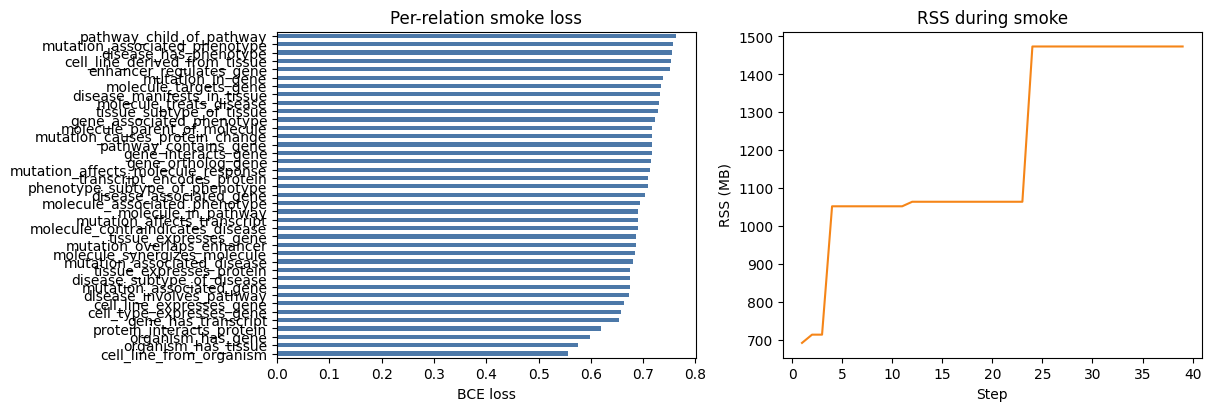

In [5]:
import matplotlib.pyplot as plt

rss_df = pd.DataFrame(pyg['rss']['samples'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
relations_df.sort_values('loss').plot.barh(x='relation', y='loss', ax=axes[0], legend=False, color='#4c78a8')
axes[0].set_title('Per-relation smoke loss')
axes[0].set_xlabel('BCE loss')
axes[0].set_ylabel('')
if not rss_df.empty:
    rss_df.plot.line(x='step', y='rss_mb', ax=axes[1], legend=False, color='#f58518')
axes[1].set_title('RSS during smoke')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('RSS (MB)')
plt.show()


## 4. LaminDB remaining work — full inventory

The current automatic writer is focused on `enhancer_regulates_gene`, because that is the huge relation currently being chunked into live LaminDB.

Important numbers:

- Source `enhancer_regulates_gene`: 48,808,144 edge rows.
- Validated live Lamin for that relation before autofinish run: 6,315,000 edge/evidence rows.
- Remaining for that relation at launch: 42,493,144 rows.
- Full edge rows remaining across the KG inventory: 95,343,377.
- Full evidence rows remaining across the KG inventory: 70,206,046.
- The autofinish cron is now processing `6.315M → 10.315M` and will continue in 4M-row runs.


In [6]:
summary = lamin['summary']
pd.Series(summary).to_frame('value')


,value
edge_rows_remaining_total,95343377
evidence_rows_remaining_total,70206046
lamin_edge_rows_total,6401291
lamin_evidence_rows_total,6359167
node_rows_remaining_total_for_mapped_tables,48966651
node_rows_source_unmapped_table_total,17633
source_edge_rows_total,101744668
source_evidence_rows_total,76565213
source_node_rows_total,55523691


In [7]:
edges_fast = pd.DataFrame(lamin['edges'])
nodes_fast = pd.DataFrame(lamin['nodes'])
evidence_fast = pd.DataFrame(lamin['evidence'])

edges_top = edges_fast.sort_values('remaining_rows', ascending=False).head(20)
nodes_top = nodes_fast.sort_values('remaining_rows', ascending=False).head(20)

display(edges_top[['relation','source_rows','lamin_rows','remaining_rows','coverage_fraction']])
display(nodes_top[['node_type','source_rows','lamin_rows','remaining_rows','status','coverage_fraction']])


,relation,source_rows,lamin_rows,remaining_rows,coverage_fraction
0,enhancer_regulates_gene,48808144,6315000,42493144,0.129384
1,cell_line_expresses_gene,20928056,0,20928056,0.000000
2,gene_interacts_gene,7424037,0,7424037,0.000000
3,tissue_expresses_gene,5338736,35000,5303736,0.006556
4,mutation_associated_disease,4656171,0,4656171,0.000000
5,molecule_synergizes_molecule,2672628,0,2672628,0.000000
6,mutation_affects_transcript,2599922,0,2599922,0.000000
7,mutation_in_gene,2599525,0,2599525,0.000000
8,mutation_overlaps_enhancer,1664278,0,1664278,0.000000
9,cell_type_expresses_gene,1561873,0,1561873,0.000000


,node_type,source_rows,lamin_rows,remaining_rows,status,coverage_fraction
4,enhancer,48808144,0.0,48808144,tracked_table,0.000000
5,gene,267830,109325.0,158505,tracked_table,0.408188
11,phenotype,16449,NaN,16449,no_exact_txgnn_table_mapped,NaN
0,cell_line,1183,NaN,1183,no_exact_txgnn_table_mapped,NaN
2,dataset,1,0.0,1,tracked_table,0.000000
7,mutation,2589509,2589508.0,1,tracked_table,1.000000
8,organism,1,NaN,1,no_exact_txgnn_table_mapped,NaN
1,cell_type,3513,3513.0,0,tracked_table,1.000000
3,disease,41859,41859.0,0,tracked_table,1.000000
6,molecule,31007,31007.0,0,tracked_table,1.000000


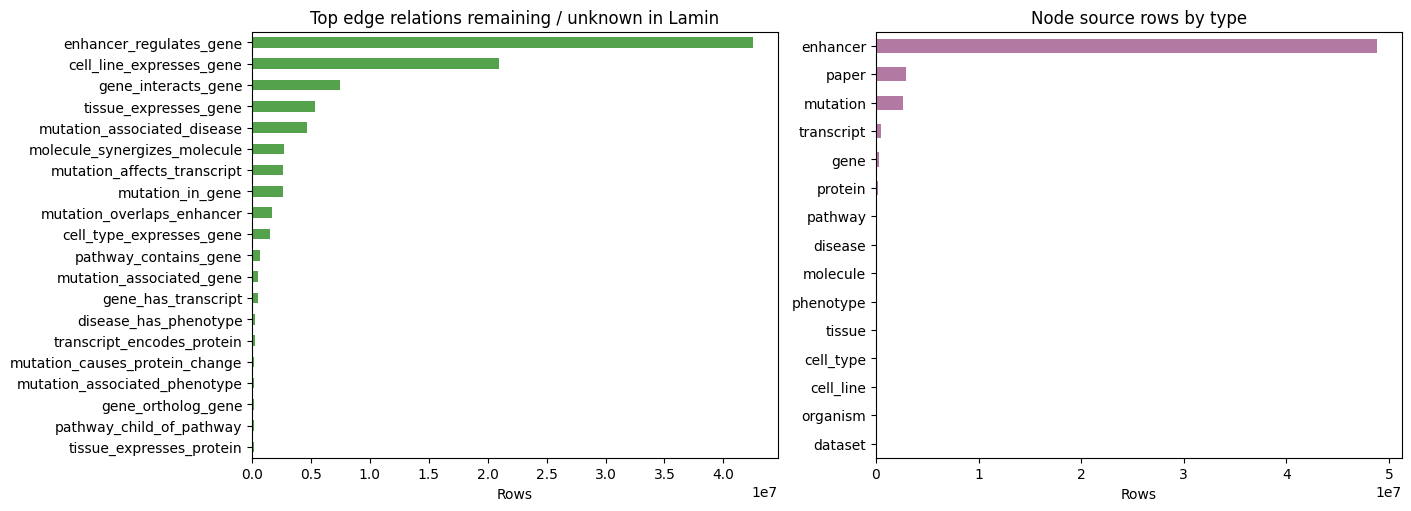

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
edges_top.sort_values('remaining_rows').plot.barh(
    x='relation', y='remaining_rows', ax=axes[0], legend=False, color='#54a24b'
)
axes[0].set_title('Top edge relations remaining / unknown in Lamin')
axes[0].set_xlabel('Rows')
axes[0].set_ylabel('')
nodes_top.sort_values('source_rows').plot.barh(
    x='node_type', y='source_rows', ax=axes[1], legend=False, color='#b279a2'
)
axes[1].set_title('Node source rows by type')
axes[1].set_xlabel('Rows')
axes[1].set_ylabel('')
plt.show()


## 5. Operational status of the autofinish loop

The loop is deliberately simple:

1. Cron every 15 min runs `~/.hermes/scripts/txgnn_lamin_enhancer_autofinish.py`.
2. That SSHes to `txgnn-worker` and runs `/home/jkobject/bin/txgnn_lamin_enhancer_autofinish.py`.
3. If any `lamin_enhancer_chunk_supervisor.py`, `run_sync_wrapper.py`, or `sync_parquet_edges_to_lamindb.py` process exists, it exits silently.
4. Otherwise it scans validated offsets and launches the next bounded supervisor run.
5. Each run handles up to 4 × 1M-row tranches and writes progress under `artifacts/reports/lamin_enhancer_autofinish/runs/...`.

Current first autofinish target at launch: `6,315,000 → 10,315,000`.


In [9]:
# Static local view: this notebook does not SSH by default.
state_path = ROOT / 'artifacts/reports/lamin_enhancer_autofinish/kg_lamin_remaining_inventory.json'
print('Inventory path:', state_path)
print('For live process state, run:')
print('  python3 ~/.hermes/scripts/txgnn_lamin_enhancer_autofinish.py --dry-run')


Inventory path: /Users/jkobject/.openclaw/workspace/work/txgnn/artifacts/reports/lamin_enhancer_autofinish/kg_lamin_remaining_inventory.json
For live process state, run:
  python3 ~/.hermes/scripts/txgnn_lamin_enhancer_autofinish.py --dry-run


## 6. What remains

### PyG

For the current acceptance criterion — true out-of-core minibatch smoke covering all non-provenance node/edge types — nothing remains: the smoke passed.

Remaining if we want to move beyond smoke:

- train for useful epochs / proper validation split;
- add real feature stores instead of fallback hashed vectors where features are absent;
- formalize metrics beyond smoke loss;
- package the remote out-of-core module into the canonical reviewable repo path if not already merged.

### LaminDB

For `enhancer_regulates_gene`, the active autofinish loop still had ~42.5M rows to ingest from the validated baseline at launch.

For all KG edges/nodes, the completed inventory says the canonical KG source currently has:

- 55,523,691 node rows;
- 101,744,668 edge rows;
- 76,565,213 evidence rows.

Live Lamin coverage at inventory time:

- 6,401,291 edge rows loaded;
- 6,359,167 evidence rows loaded;
- 95,343,377 edge rows remaining;
- 70,206,046 evidence rows remaining.

Main mapped node gaps: enhancer nodes (48,808,144), gene rows (158,505), dataset (1), mutation (1); organism/phenotype/cell_line need exact TxGNN table mapping rather than simple row sync.
